In [14]:
# Import libraries
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

In [ ]:
#1 Define dissimilarity matrix
# Observations: A, B, C, D
dissimilarity_matrix = np.array([
    [0.0, 0.3, 0.4, 0.7],
    [0.3, 0.0, 0.5, 0.8],
    [0.4, 0.5, 0.0, 0.45],
    [0.7, 0.8, 0.45, 0.0]
])


In [ ]:
# Convert square dissimilarity matrix into condensed form
condensed_dist = squareform(dissimilarity_matrix)

labels = ['A', 'B', 'C', 'D']

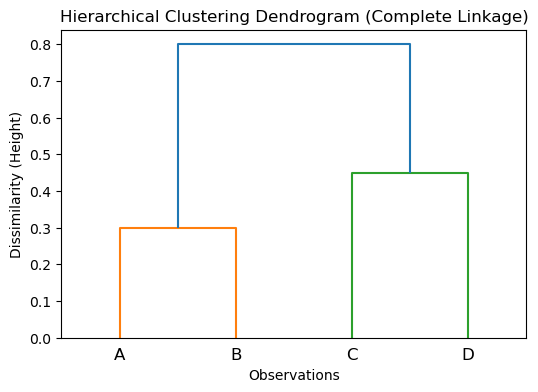

In [36]:
#2 Complete linkage clustering
Z_complete = linkage(condensed_dist, method='complete')

plt.figure(figsize=(6, 4))
dendrogram(Z_complete, labels=labels)
plt.title("Hierarchical Clustering Dendrogram (Complete Linkage)")
plt.xlabel("Observations")
plt.ylabel("Dissimilarity (Height)")
plt.show()


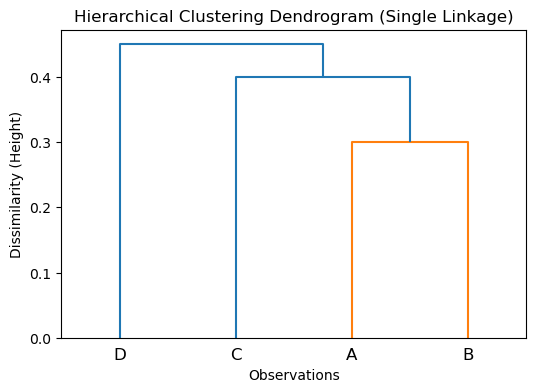

In [37]:
Z_single = linkage(condensed_dist, method='single')

plt.figure(figsize=(6, 4))
dendrogram(Z_single, labels=labels)
plt.title("Hierarchical Clustering Dendrogram (Single Linkage)")
plt.xlabel("Observations")
plt.ylabel("Dissimilarity (Height)")
plt.show()



In [25]:
#3 Cut complete linkage dendrogram to form 2 clusters
clusters_complete = fcluster(Z_complete, t=2, criterion='maxclust')
print("Complete Linkage - 2 Clusters:", dict(zip(labels, clusters_complete)))


Complete Linkage - 2 Clusters: {'A': np.int32(1), 'B': np.int32(1), 'C': np.int32(2), 'D': np.int32(2)}


In [ ]:
→ A,B together; C,D together

In [26]:
#4 Cut single linkage dendrogram to form 2 clusters
clusters_single = fcluster(Z_single, t=2, criterion='maxclust')
print("Single Linkage - 2 Clusters:", dict(zip(labels, clusters_single)))

Single Linkage - 2 Clusters: {'A': np.int32(1), 'B': np.int32(1), 'C': np.int32(1), 'D': np.int32(2)}


→ A,B,C together; D alone

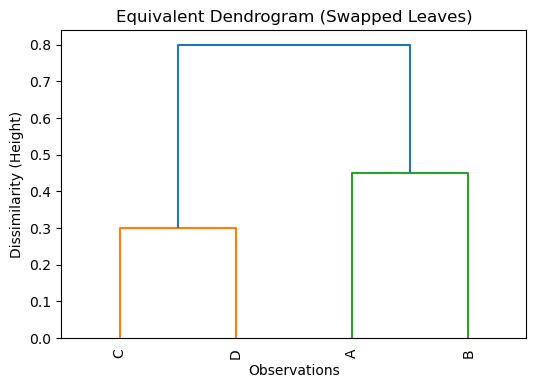

In [43]:
#5 Swapped label order
plt.figure(figsize=(6, 4))
dendrogram(
    Z_complete,
    labels=['C', 'D', 'A', 'B'],  # rearranged order
    leaf_rotation=90,
    leaf_font_size=10
)
plt.title("Equivalent Dendrogram (Swapped Leaves)")
plt.xlabel("Observations")
plt.ylabel("Dissimilarity (Height)")
plt.show()